# Electricity, costs and national comparison

Indonesia only. A/E/B/S labels and source boundaries remain in datasets. These calculations are scenarios, not metered national data-center electricity or water. See docs/methodology.md.

In [1]:
from pathlib import Path
import sys
root = Path.cwd().resolve()
while not (root / 'assumptions.yaml').exists():
    if root == root.parent: raise FileNotFoundError('Run from within the research repository')
    root = root.parent
sys.path.insert(0, str(root / 'src'))
import pandas as pd
from IPython.display import display, Image
from config import read_dataset, assumptions


In [2]:
from electricity_model import electricity, mva_to_mw
display(pd.DataFrame([electricity(1000, .8, 1.3, assumptions()['tariffs']['electricity_rp_per_kwh'])]))
print('100 MVA at the configured power factor is connection MW, not IT MW:', mva_to_mw(100, assumptions()['power_factor']['base']))

,it_electricity_mwh,it_electricity_gwh,it_electricity_twh,it_electricity_kwh,facility_electricity_mwh,facility_electricity_gwh,facility_electricity_twh,facility_electricity_kwh,monthly_electricity_gwh,electricity_cost_rp,monthly_electricity_cost_rp,electricity_cost_rp_per_mw_it,average_facility_load_mw,full_it_load_facility_mw
0,7008000.0,7008.0,7.008,7.008000e+09,9110400.0,9110.4,9.1104,9.110400e+09,759.2,9.080700e+12,7.567250e+11,9.080700e+09,1040.0,1300.0


100 MVA at the configured power factor is connection MW, not IT MW: 95.0


In [3]:
display(read_dataset('electricity_tariffs'))
display(read_dataset('additional_1gw')[['case','utilization','pue','it_electricity_gwh','facility_electricity_twh','electricity_cost_rp','share_national_consumption_pct','share_pln_sales_pct']])

,customer_class,voltage_level,tariff_rp_per_kwh,effective_period,notes,source_id,data_class,tariff_block,minimum_connection_kva,minimum_connection_exclusive,peak_multiplier_min,peak_multiplier_max,reactive_tariff_rp_per_kvarh
0,B-3,TM / TT (medium / high voltage),1035.78,2026-07-01/2026-09-30,Published energy component; excludes negotiate...,ELEC002,A,LWBP,200.0,True,1.4,2.0,1114.74
1,B-3,TM / TT (medium / high voltage),NaN,2026-07-01/2026-09-30,Published energy component; excludes negotiate...,ELEC002,A,WBP,200.0,True,1.4,2.0,1114.74
2,I-3,TM (medium voltage),1035.78,2026-07-01/2026-09-30,Published energy component; excludes negotiate...,ELEC002,A,LWBP,200.0,True,1.4,2.0,1114.74
3,I-3,TM (medium voltage),NaN,2026-07-01/2026-09-30,Published energy component; excludes negotiate...,ELEC002,A,WBP,200.0,True,1.4,2.0,1114.74
4,I-4,TT (high voltage),996.74,2026-07-01/2026-09-30,Published energy component; excludes negotiate...,ELEC002,A,WBP + LWBP,30000.0,False,1.0,1.0,996.74
5,Premium electricity / bespoke high-voltage con...,Site-specific medium / high voltage,NaN,Not publicly disclosed for a representative DC...,No validated site-specific premium-service quo...,ELEC002,E,contract specific,NaN,NaN,NaN,NaN,NaN


,case,utilization,pue,it_electricity_gwh,facility_electricity_twh,electricity_cost_rp,share_national_consumption_pct,share_pln_sales_pct
0,low,0.60,1.2,5256,6.3072,6.286639e+12,1.386195,1.985319
1,base,0.80,1.3,7008,9.1104,9.080700e+12,2.002281,2.867683
2,high,0.95,1.5,8322,12.4830,1.244231e+13,2.743510,3.929277


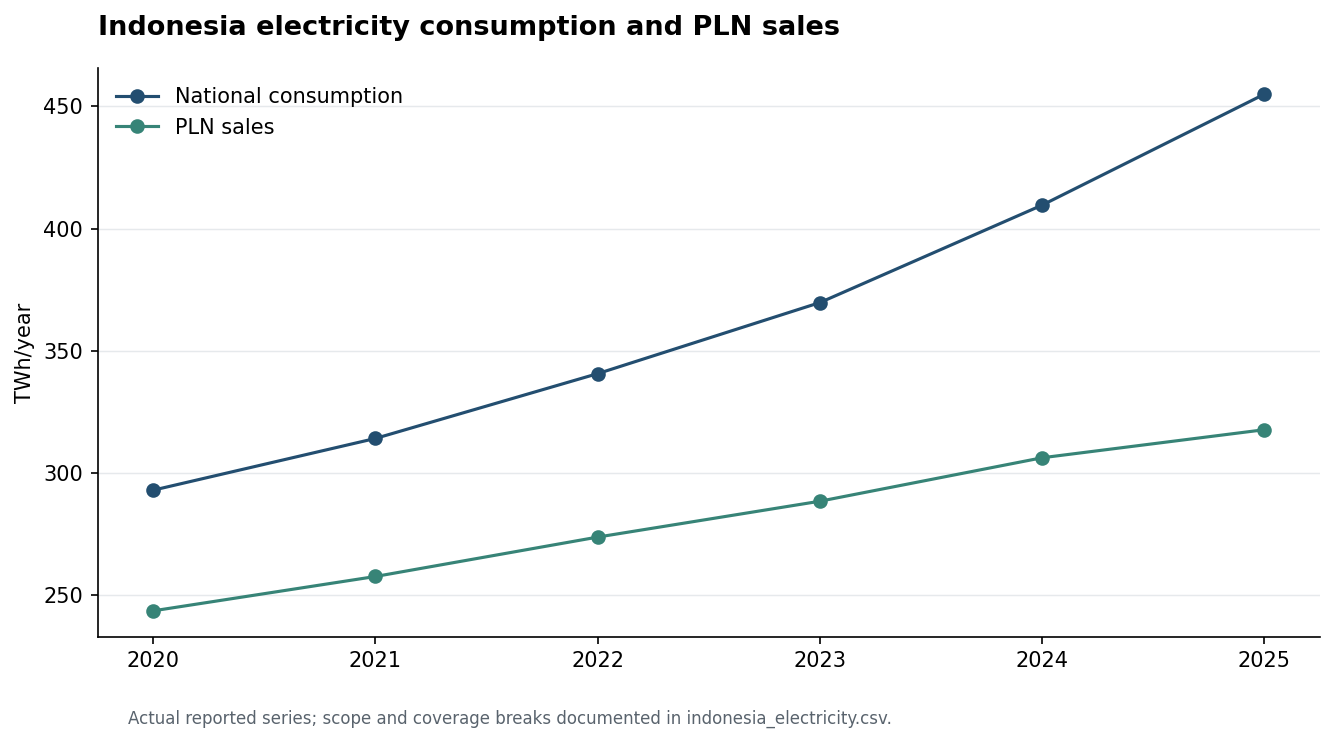

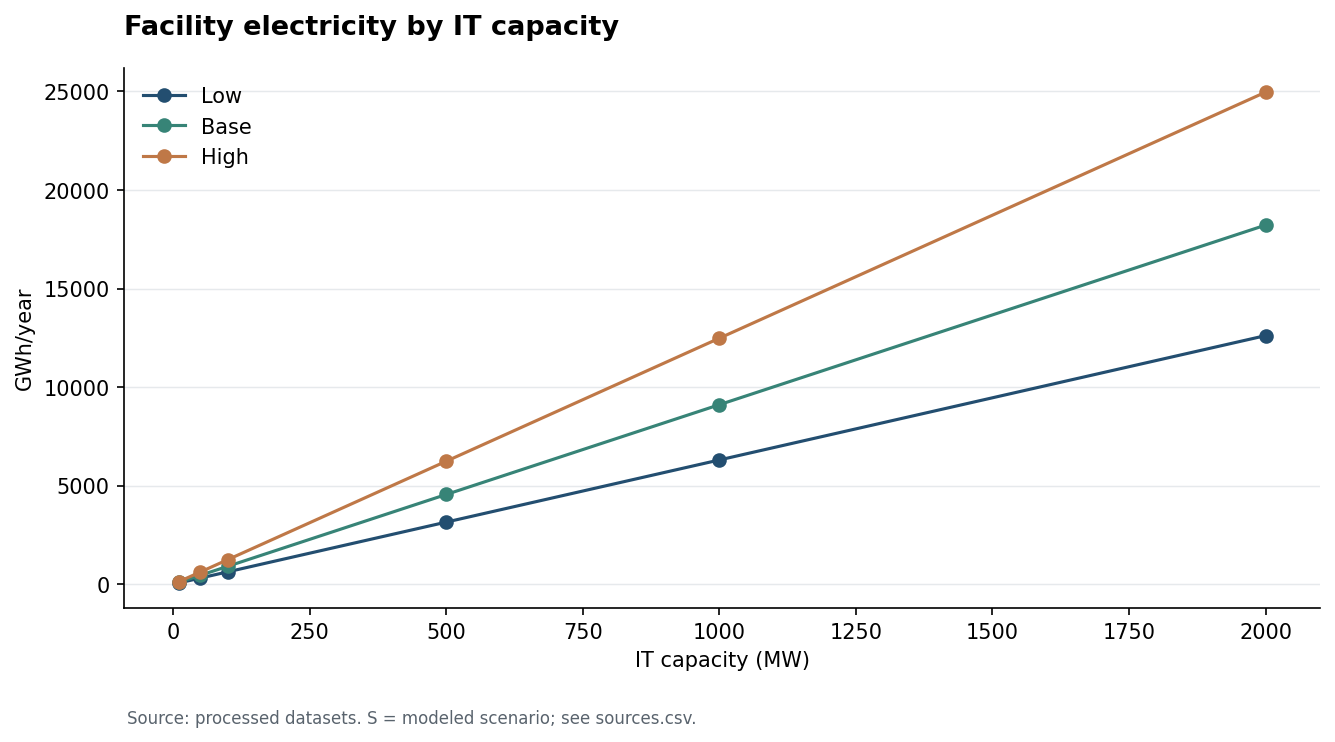

In [4]:
display(Image(filename=str(root / 'outputs/charts/03_electricity_trend.png')))
display(Image(filename=str(root / 'outputs/charts/04_facility_electricity.png')))